In [1]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

In [2]:
A = np.array([[1, 1],
              [0, 1]])
B = np.array([[0],
              [1]])
C = np.array([[1, 0]])
D = np.array([[0]])

In [3]:
dt = 1.0

In [4]:
# Cost matrices (LQR)
Q = np.diag([10, 1])
R = np.array([[1]])

In [5]:
# Noise covariances (Kalman)
Qn = np.diag([0.01, 0.01])
Rn = np.array([[0.1]])

In [6]:
# LQR controller
K, _, _ = ct.dlqr(A, B, Q, R)

In [7]:
# Kalman filter
L, _, _ = ct.dlqe(A, np.eye(2), C, Qn, Rn)

In [8]:
# Simulation
N = 50
x = np.zeros((2, N))
x_hat = np.zeros((2, N))
u = np.zeros(N)
y = np.zeros(N)

In [9]:
# Initial condition (non-zero!)
x[:, 0] = [5, 0]

In [10]:
np.random.seed(1)

In [11]:
for k in range(N-1):
    # Control using estimated state
    u[k] = (-K @ x_hat[:, k]).item()

    # Noise
    w = np.random.multivariate_normal([0, 0], Qn)
    v = np.random.normal(0, np.sqrt(Rn[0,0]))

    # True system
    x[:, k+1] = A @ x[:, k] + B.flatten()*u[k] + w
    y[k] = (C @ x[:, k]).item() + v

    # State estimation
    x_hat[:, k+1] = A @ x_hat[:, k] + B.flatten()*u[k] \
                    + L @ (y[k] - C @ x_hat[:, k])

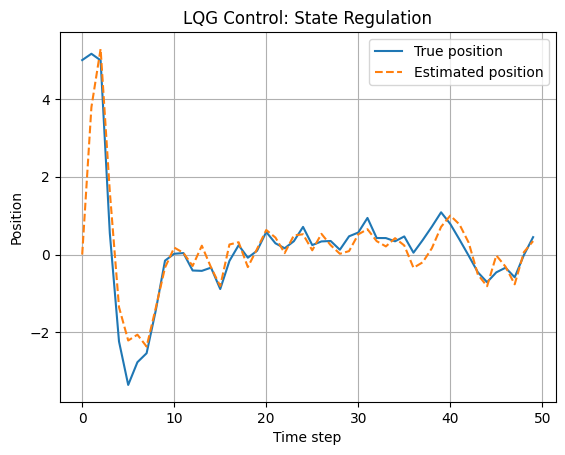

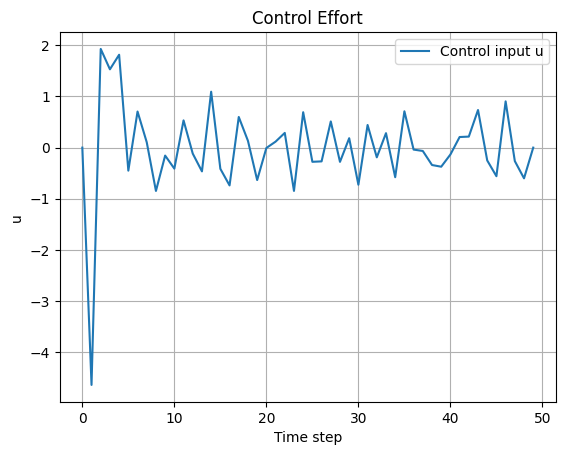

In [12]:
# Plot states
plt.figure()
plt.plot(x[0, :], label="True position")
plt.plot(x_hat[0, :], '--', label="Estimated position")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.legend()
plt.title("LQG Control: State Regulation")
plt.grid()

# Plot control input
plt.figure()
plt.plot(u, label="Control input u")
plt.xlabel("Time step")
plt.ylabel("u")
plt.legend()
plt.title("Control Effort")
plt.grid()

plt.show()